# Stage 1 — Risk Profile Classification (Experiment Notebook)

An interactive, visual companion to `src/train_models.py`, focused **only** on the first stage of the pipeline: classifying an investor into one of three risk profiles.

This notebook is designed to:

- **Showcase** the full classification workflow end-to-end
- **Explain** how Grid Search and cross-validation work
- **Let you experiment** by changing a single variable and re-running
- Compare five different model families on the same data

Nothing is written to disk — the production training script (`src/train_models.py`) owns saved models and reports.

## 1. What this classifier predicts

Given an investor's demographic, financial, and behavioural features, the model predicts their **risk profile** — one of:

| Class | Meaning |
|---|---|
| **Aggressive** | High risk tolerance, long horizon → heavy equity tilt |
| **Moderate** | Mid-risk → balanced equity / bond mix |
| **Conservative** | Low risk tolerance, short horizon → bond tilt |

This is **Stage 1** of a 4-stage pipeline. The risk profile flows downstream to:

1. **(this notebook)** Risk profile classification
2. Asset allocation regression (equity % vs bond %)
3. Total ETF count regression
4. Rule-based ETF ticker selection

**Inputs:** 19 features (6 scaled numerics + 13 one-hot encoded categoricals) prepared in `notebooks/phase2_data_preparation.ipynb`.

**Random baseline:** a coin-flip 3-class guesser would score **33.3%** accuracy. Anything above that line is genuinely learning something.

## 2. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

DATA_DIR = '../data/training'
print('Libraries imported.')

Libraries imported.


## 3. Experiment Controls

**This is the only cell you usually need to touch.** Change a value here and run all cells below to see how it affects model selection.

| Variable | What it controls |
|---|---|
| `SCORING_METRIC` | Metric Grid Search optimises (`'accuracy'` or `'f1_macro'` are the usual choices — any sklearn scorer works) |
| `CV_FOLDS` | Number of cross-validation folds inside Grid Search. Higher = more reliable but slower |
| `RANDOM_STATE` | Seed for reproducibility — same seed = same results |
| `RUN_GRID_SEARCH` | If `False`, models are fit with default hyperparameters (much faster, no tuning) |
| `PARAM_GRIDS` | The hyperparameter values searched for each model |

In [2]:
# ===== EDIT ME =====
SCORING_METRIC  = 'accuracy'   # try 'f1_macro' and re-run to see selection change
CV_FOLDS        = 5
RANDOM_STATE    = 42
RUN_GRID_SEARCH = True

# Small grids — fast enough for repeated runs during a demo.
# Add/remove values freely; the notebook will adapt.
PARAM_GRIDS = {
    'KNN': {
        'n_neighbors': [5, 15, 25],
        'weights':     ['uniform', 'distance'],
    },
    'Logistic Regression': {
        'C':       [0.1, 1.0, 10.0],   # inverse regularisation strength
        'penalty': ['l2'],
    },
    'Random Forest': {
        'n_estimators':      [100, 200, 500],
        'max_depth':         [None, 5, 10, 15],
        'min_samples_split': [2, 5, 7],
    },
    'XGBoost': {
        'n_estimators':  [100, 200, 500],
        'max_depth':     [4, 6],
        'learning_rate': [0.1],
    },
    'MLP': {
        'hidden_layer_sizes': [(64,), (128, 64)],
        'alpha':              [1e-4, 1e-3],
    },
}

print(f'Scoring metric:     {SCORING_METRIC}')
print(f'CV folds:           {CV_FOLDS}')
print(f'Random state:       {RANDOM_STATE}')
print(f'Run grid search:    {RUN_GRID_SEARCH}')

Scoring metric:     accuracy
CV folds:           5
Random state:       42
Run grid search:    True


## 4. Load the prepared training data

The features (`X`) and labels (`y`) were prepared in `phase2_data_preparation.ipynb` using an 80/20 stratified split. We re-use those exact splits so results in this notebook are directly comparable to the production training script.

In [3]:
X_train = pd.read_csv(f'{DATA_DIR}/X_train.csv')
X_test  = pd.read_csv(f'{DATA_DIR}/X_test.csv')

y_train = pd.read_csv(f'{DATA_DIR}/y_train_profile.csv')['risk_profile']
y_test  = pd.read_csv(f'{DATA_DIR}/y_test_profile.csv')['risk_profile']

print(f'Train: {X_train.shape[0]:>5} rows  |  Test: {X_test.shape[0]:>5} rows')
print(f'Features: {X_train.shape[1]}')
X_train.head()

Train:  4000 rows  |  Test:  1000 rows
Features: 19


,age,HouseholdSize,income,horizon,InvestmentCapital,experience,Gender_Male,Education_High school,Education_Master,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,InvestmentGoal_Home purchase,InvestmentGoal_Other,InvestmentGoal_Retirement,risk_tolerance_Low,risk_tolerance_Medium,FinancialInvolvement_Low,FinancialInvolvement_Medium
0,0.2893,-1.3907,0.0186,0.2423,-0.4815,-0.8076,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000
1,1.3758,0.5538,-0.9640,-0.6332,-0.4239,0.5174,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000
2,-0.4712,0.5538,0.5601,-0.3049,-0.0871,-0.3399,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000
3,-0.5255,-0.4184,1.3133,2.1027,0.9760,0.0497,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000
4,-0.7428,-0.4184,-0.2088,-0.4143,-0.0126,-0.5738,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000


## 5. Understanding the target classes

Before any modelling, look at the labels. If the dataset is heavily imbalanced (e.g. 90% of one class), **accuracy can be misleading** — a dumb model that always predicts the majority class would score 90%. This is one of the main reasons to look at **macro F1** as well as accuracy.

In [4]:
class_counts = pd.concat(
    [y_train.value_counts().rename('train'),
     y_test.value_counts().rename('test')],
    axis=1
).assign(
    train_pct=lambda d: 100 * d['train'] / d['train'].sum(),
    test_pct =lambda d: 100 * d['test']  / d['test'].sum(),
)
class_counts

,train,test,train_pct,test_pct
risk_profile,,,,
Moderate,1515,378,37.8750,37.8000
Conservative,1246,312,31.1500,31.2000
Aggressive,1239,310,30.9750,31.0000


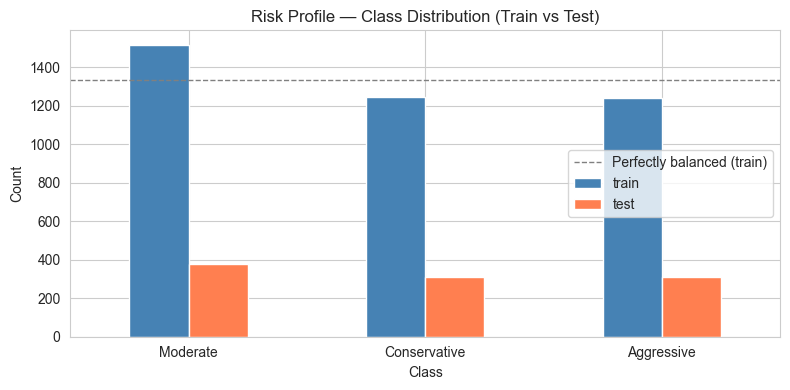

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
class_counts[['train', 'test']].plot.bar(ax=ax, color=['steelblue', 'coral'])
ax.set_title('Risk Profile — Class Distribution (Train vs Test)')
ax.set_ylabel('Count')
ax.set_xlabel('Class')
ax.tick_params(axis='x', rotation=0)
ax.axhline(len(y_train) / 3, ls='--', color='grey', lw=1, label='Perfectly balanced (train)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. The concepts — quick primer

### 6.1 Hyperparameters

Hyperparameters are the **dials you set before training**. The model doesn't learn them from data — you choose them.

Examples in this notebook:
- KNN's `n_neighbors` — how many "similar investors" to consult
- Random Forest's `max_depth` — how deep each tree is allowed to grow
- MLP's `hidden_layer_sizes` — the shape of the neural network

Different hyperparameters can mean the difference between a useless model and a great one.

### 6.2 Grid Search

Trying every combination of a defined set of hyperparameter values, then picking the best. For example:

```
n_neighbors: [5, 15, 25]    # 3 values
weights:     ['uniform',    # 2 values
              'distance']
```

→ **3 × 2 = 6 combinations** to test.

### 6.3 Cross-validation (CV)

Each candidate combination is evaluated **not** on the test set but by splitting the training data into K folds (here, `CV_FOLDS=5`):

1. Train on folds 1-4, score on fold 5
2. Train on folds 1,2,3,5, score on fold 4
3. … five times in total
4. Average the five scores → that's the candidate's CV score

So a 6-combination grid with 5-fold CV runs **6 × 5 = 30 model fits** under the hood. Grid Search returns the combination with the best average CV score.

### 6.4 Why not tune directly on the test set?

If you use the test set to pick hyperparameters, the test set is no longer an **independent** estimate of how well the model will do on new data — you've leaked information into your model selection. The test set becomes optimistically biased. CV solves this by keeping the test set untouched until the very end.

### 6.5 Accuracy vs Macro F1

| | Accuracy | Macro F1 |
|---|---|---|
| **What** | Fraction of predictions that are correct overall | F1 score computed per class, then averaged equally |
| **Strength** | Easy to understand, useful when classes are balanced | Penalises a model that ignores any single class |
| **Weakness** | Can be misleading on imbalanced data | Less intuitive |

On a 3-class problem with roughly balanced classes, the two are usually close. They diverge when a model is good at the majority class but bad at minority classes — exactly the failure mode you care about catching.

### 6.6 Confusion matrix

A K×K table where rows are true labels and columns are predictions. Diagonal cells = correct, off-diagonals = where the model confuses one class for another. Often more informative than a single number.

### 6.7 How to decide which model is best

Pick the model whose **test-set score on the metric you care about** is highest, after using CV to tune hyperparameters fairly. If two models tie, prefer the simpler / faster one.

## 7. Helpers

XGBoost requires integer-encoded labels, so we build a label map and a small helper that runs Grid Search and computes every metric we want.

In [6]:
# Integer encoding for XGBoost (and any other estimator that wants int labels)
label_map     = {'Aggressive': 0, 'Conservative': 1, 'Moderate': 2}
inv_label_map = {v: k for k, v in label_map.items()}
y_train_enc   = y_train.map(label_map)
y_test_enc    = y_test.map(label_map)
CLASSES       = ['Aggressive', 'Moderate', 'Conservative']


def evaluate_model(name, estimator, param_grid, requires_int_labels=False):
    """Run GridSearchCV (or a plain fit) and return a dict of every metric we care about."""
    y_tr = y_train_enc if requires_int_labels else y_train
    y_te = y_test_enc  if requires_int_labels else y_test

    n_combos = int(np.prod([len(v) for v in param_grid.values()])) if param_grid else 1
    n_fits   = n_combos * CV_FOLDS

    if RUN_GRID_SEARCH and param_grid:
        gs = GridSearchCV(estimator, param_grid, cv=CV_FOLDS,
                          scoring=SCORING_METRIC, n_jobs=-1)
        gs.fit(X_train, y_tr)
        best_model    = gs.best_estimator_
        best_params   = gs.best_params_
        best_cv_score = gs.best_score_
    else:
        estimator.fit(X_train, y_tr)
        best_model    = estimator
        best_params   = '(no grid search)'
        best_cv_score = np.nan

    train_pred = best_model.predict(X_train)
    test_pred  = best_model.predict(X_test)

    # Decode predictions back to string labels so metrics are comparable across models
    if requires_int_labels:
        train_pred = pd.Series(train_pred).map(inv_label_map).values
        test_pred  = pd.Series(test_pred).map(inv_label_map).values

    train_acc = accuracy_score(y_train, train_pred)
    test_acc  = accuracy_score(y_test,  test_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, test_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_test, test_pred, labels=CLASSES)

    # Print a clean per-model summary
    print(f'  Grid: {n_combos} combos × {CV_FOLDS} folds = {n_fits} fits')
    print(f'  Best params:        {best_params}')
    if not np.isnan(best_cv_score):
        print(f'  Best CV {SCORING_METRIC:<10} {best_cv_score:.4f}')
    print(f'  Train accuracy:     {train_acc:.4f}')
    print(f'  Test accuracy:      {test_acc:.4f}')
    print(f'  Test macro F1:      {f1:.4f}')

    return {
        'name':            name,
        'best_params':     best_params,
        'best_cv_score':   best_cv_score,
        'train_acc':       train_acc,
        'test_acc':        test_acc,
        'macro_precision': prec,
        'macro_recall':    rec,
        'macro_f1':        f1,
        'cm':              cm,
        'model':           best_model,
    }


def plot_cm(cm, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.5, 3.8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')


results = {}  # collected across all five training cells
print('Helpers ready.')

Helpers ready.


## 8. Train and tune each model

Each model below follows the same pattern:

1. Define the estimator
2. Look up its grid in `PARAM_GRIDS`
3. Hand both to `evaluate_model` — it runs Grid Search, computes metrics, and prints a summary
4. Plot its confusion matrix

The behaviour of every cell is controlled by the variables in **Experiment Controls** above.

### 8.1 KNN — geometric baseline

K-Nearest Neighbours makes no assumption about the data — it classifies a new investor by looking at the `n_neighbors` most similar investors in the training set and taking a vote. Sensitive to the **scale** of features, which is why our features were standardised in Phase 2.

--- KNN ---
  Grid: 6 combos × 5 folds = 30 fits
  Best params:        {'n_neighbors': 25, 'weights': 'distance'}
  Best CV accuracy   0.4245
  Train accuracy:     1.0000
  Test accuracy:      0.4040
  Test macro F1:      0.4037


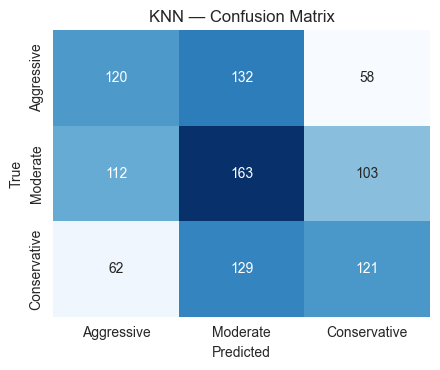

In [7]:
print('--- KNN ---')
results['KNN'] = evaluate_model(
    'KNN',
    KNeighborsClassifier(),
    PARAM_GRIDS['KNN'],
)
plot_cm(results['KNN']['cm'], 'KNN — Confusion Matrix')
plt.tight_layout()
plt.show()

### 8.2 Logistic Regression — linear baseline

Tests whether the three classes are **linearly separable** in feature space. If LR performs comparably to the tree-based models, the problem is essentially linear and a simpler model would do. `C` is the inverse regularisation strength — smaller = more regularisation.

--- Logistic Regression ---
  Grid: 3 combos × 5 folds = 15 fits
  Best params:        {'C': 0.1, 'penalty': 'l2'}
  Best CV accuracy   0.4460
  Train accuracy:     0.4547
  Test accuracy:      0.4310
  Test macro F1:      0.4272


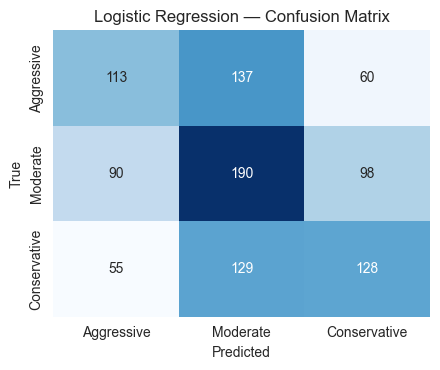

In [8]:
print('--- Logistic Regression ---')
results['Logistic Regression'] = evaluate_model(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1),
    PARAM_GRIDS['Logistic Regression'],
)
plot_cm(results['Logistic Regression']['cm'], 'Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

### 8.3 Random Forest — bagged decision trees

Trains many decision trees on bootstrap samples of the data. Each split considers a random feature subset, which decorrelates the trees and reduces variance. Strong baseline for tabular data and produces a **feature importance** ranking we'll plot at the end.

--- Random Forest ---


/Users/avivberkovich/Documents/AI_FINANCIAL_ADVISOR/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/avivberkovich/Documents/AI_FINANCIAL_ADVISOR/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/avivberkovich/Documents/AI_FINANCIAL_ADVISOR/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the jobl

  Grid: 36 combos × 5 folds = 180 fits
  Best params:        {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
  Best CV accuracy   0.4580
  Train accuracy:     0.5040
  Test accuracy:      0.4360
  Test macro F1:      0.4307


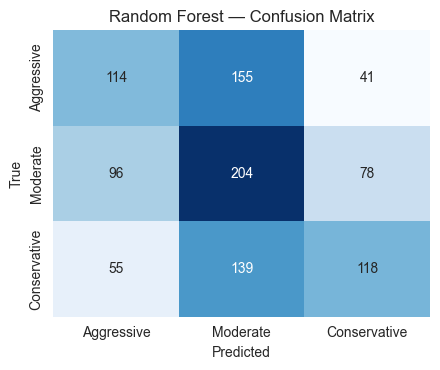

In [9]:
print('--- Random Forest ---')
results['Random Forest'] = evaluate_model(
    'Random Forest',
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    PARAM_GRIDS['Random Forest'],
)
plot_cm(results['Random Forest']['cm'], 'Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

### 8.4 XGBoost — gradient boosted trees

Builds trees **sequentially**: each new tree corrects the errors of the previous ensemble. Often state-of-the-art on tabular problems. Note the integer label encoding.

--- XGBoost ---
  Grid: 6 combos × 5 folds = 30 fits
  Best params:        {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
  Best CV accuracy   0.4383
  Train accuracy:     0.6112
  Test accuracy:      0.4160
  Test macro F1:      0.4126


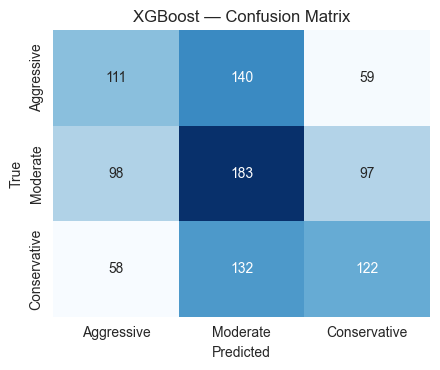

In [10]:
print('--- XGBoost ---')
results['XGBoost'] = evaluate_model(
    'XGBoost',
    XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                  eval_metric='mlogloss', verbosity=0),
    PARAM_GRIDS['XGBoost'],
    requires_int_labels=True,
)
plot_cm(results['XGBoost']['cm'], 'XGBoost — Confusion Matrix')
plt.tight_layout()
plt.show()

### 8.5 MLP — multi-layer perceptron (neural network)

A small feed-forward neural network. Tests whether there are deep non-linear patterns that tree-based models miss. Slower to train than the others. We also use integer labels to side-step a known sklearn/Python 3.14 quirk with string targets.

--- MLP ---
  Grid: 4 combos × 5 folds = 20 fits
  Best params:        {'alpha': 0.0001, 'hidden_layer_sizes': (64,)}
  Best CV accuracy   0.4075
  Train accuracy:     0.5980
  Test accuracy:      0.4170
  Test macro F1:      0.4176


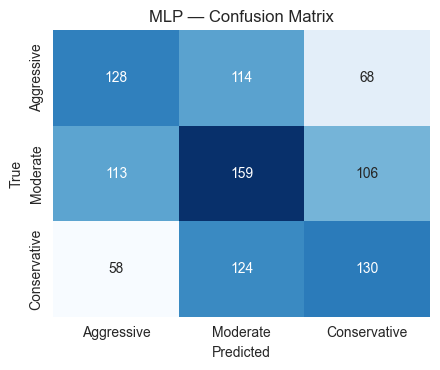

In [11]:
print('--- MLP ---')
results['MLP'] = evaluate_model(
    'MLP',
    MLPClassifier(activation='relu', max_iter=500, random_state=RANDOM_STATE),
    PARAM_GRIDS['MLP'],
    requires_int_labels=True,
)
plot_cm(results['MLP']['cm'], 'MLP — Confusion Matrix')
plt.tight_layout()
plt.show()

## 9. Model comparison

Side-by-side view of every model. The **`SCORING_METRIC`** column (highlighted in the bar charts below) is the metric Grid Search optimised — but every metric is computed regardless so you can see the trade-offs.

In [12]:
comparison = pd.DataFrame([
    {
        'Model':           r['name'],
        'Best Params':     str(r['best_params']),
        'Train Accuracy':  r['train_acc'],
        'Test Accuracy':   r['test_acc'],
        'Macro Precision': r['macro_precision'],
        'Macro Recall':    r['macro_recall'],
        'Macro F1':        r['macro_f1'],
    }
    for r in results.values()
]).set_index('Model')

comparison.style.format({
    'Train Accuracy':  '{:.4f}',
    'Test Accuracy':   '{:.4f}',
    'Macro Precision': '{:.4f}',
    'Macro Recall':    '{:.4f}',
    'Macro F1':        '{:.4f}',
}).background_gradient(subset=['Test Accuracy', 'Macro F1'], cmap='Blues')

,Best Params,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1
Model,,,,,,
KNN,"{'n_neighbors': 25, 'weights': 'distance'}",1.0000,0.4040,0.4072,0.4020,0.4037
Logistic Regression,"{'C': 0.1, 'penalty': 'l2'}",0.4547,0.4310,0.4341,0.4258,0.4272
Random Forest,"{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}",0.5040,0.4360,0.4459,0.4285,0.4307
XGBoost,"{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}",0.6112,0.4160,0.4189,0.4111,0.4126
MLP,"{'alpha': 0.0001, 'hidden_layer_sizes': (64,)}",0.5980,0.4170,0.4187,0.4167,0.4176


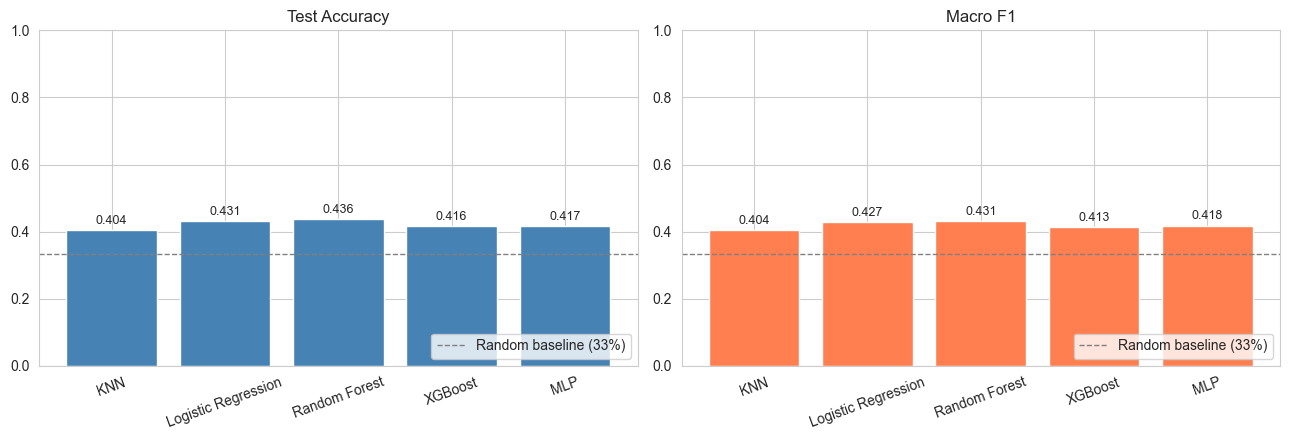

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, col, color in [
    (axes[0], 'Test Accuracy', 'steelblue'),
    (axes[1], 'Macro F1',      'coral'),
]:
    bars = ax.bar(comparison.index, comparison[col], color=color)
    ax.set_title(col)
    ax.set_ylim(0, 1)
    ax.axhline(1/3, ls='--', color='grey', lw=1, label='Random baseline (33%)')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(loc='lower right')
    for bar, val in zip(bars, comparison[col]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

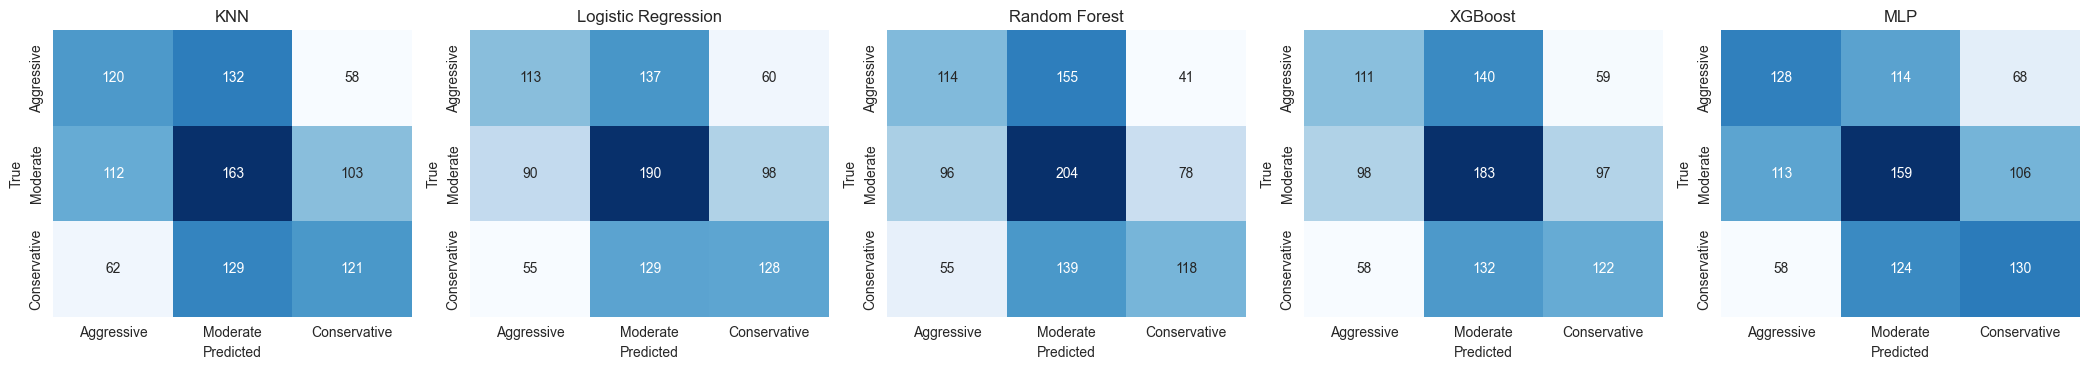

In [14]:
# Every confusion matrix side-by-side — easier to compare error patterns
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.8))
for ax, (name, r) in zip(axes, results.items()):
    plot_cm(r['cm'], name, ax=ax)
plt.tight_layout()
plt.show()

## 10. Final model selection

The winner is chosen by the metric you set in `SCORING_METRIC`. Change that variable above and re-run — the winner may change.

Mapping from `SCORING_METRIC` to the column we rank by:

| `SCORING_METRIC` | Ranked by |
|---|---|
| `'accuracy'` | Test Accuracy |
| `'f1_macro'` | Macro F1 |
| anything else | Macro F1 (fallback) |

Optimising for:  accuracy  → ranking by "Test Accuracy"
WINNER:          Random Forest
  Test Accuracy: 0.4360
  Macro F1:      0.4307
  Best params:   {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}


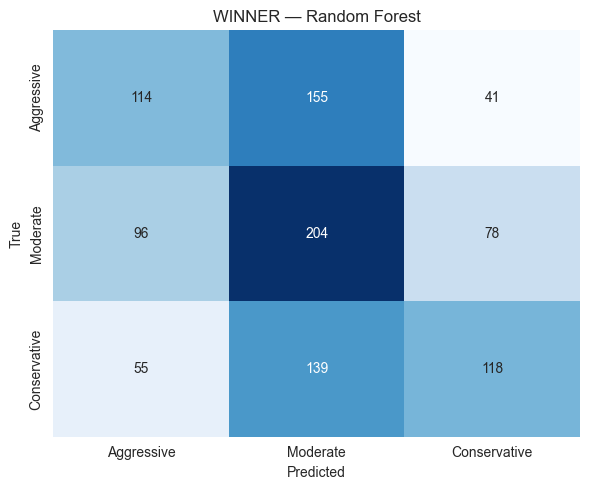

In [15]:
metric_to_col = {'accuracy': 'Test Accuracy', 'f1_macro': 'Macro F1'}
rank_col      = metric_to_col.get(SCORING_METRIC, 'Macro F1')

winner_name = comparison[rank_col].idxmax()
winner      = results[winner_name]

print(f'Optimising for:  {SCORING_METRIC}  → ranking by "{rank_col}"')
print(f'WINNER:          {winner_name}')
print(f'  Test Accuracy: {winner["test_acc"]:.4f}')
print(f'  Macro F1:      {winner["macro_f1"]:.4f}')
print(f'  Best params:   {winner["best_params"]}')

fig, ax = plt.subplots(figsize=(6, 5))
plot_cm(winner['cm'], f'WINNER — {winner_name}', ax=ax)
plt.tight_layout()
plt.show()

### Feature importance

Tree-based models expose feature importances directly. We plot them from the Random Forest because:

- Importances are **always available** from a fitted `RandomForestClassifier`
- They're comparable across runs regardless of which model won
- Linear/MLP/KNN do not provide a clean equivalent

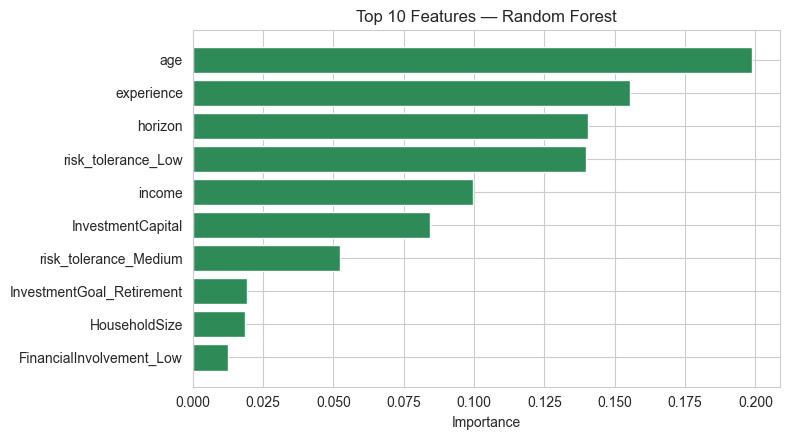

In [16]:
rf_model = results['Random Forest']['model']
fi = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': rf_model.feature_importances_,
}).sort_values('importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(fi['feature'][::-1], fi['importance'][::-1], color='seagreen')
ax.set_xlabel('Importance')
ax.set_title('Top 10 Features — Random Forest')
plt.tight_layout()
plt.show()

## 11. Experiment area

Some prompts to try. Each one is **one variable change** in section 3, then re-run all cells.

1. **Swap the scoring metric.** Change `SCORING_METRIC = 'accuracy'` to `SCORING_METRIC = 'f1_macro'`. Does the winner change? Why or why not?
2. **Push the KNN grid.** Add `51` and `101` to `n_neighbors` — does a much smoother decision boundary help or hurt?
3. **Shrink the Random Forest.** Set `n_estimators: [10, 25]` and `max_depth: [3, 5]`. How big is the gap to the un-shrunk version?
4. **Turn off Grid Search.** Set `RUN_GRID_SEARCH = False` — every model runs with its sklearn / xgboost defaults. How much does tuning actually buy you here?
5. **Cheap CV.** Set `CV_FOLDS = 3` and time the run. Then set `CV_FOLDS = 10`. Are the winners the same?
6. **Add a new metric to the table.** In `evaluate_model`, add a `balanced_accuracy_score` row and rerun.

Use the empty cells below to try things out without scrolling back up.

In [17]:
# Scratch cell — try things here


In [18]:
# Scratch cell — try things here
